In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasad22/healthcare-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'healthcare-dataset' dataset.
Path to dataset files: /kaggle/input/healthcare-dataset


In [14]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [17]:
df.isnull().sum()


,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [18]:
print(df["Medical Condition"].value_counts())

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


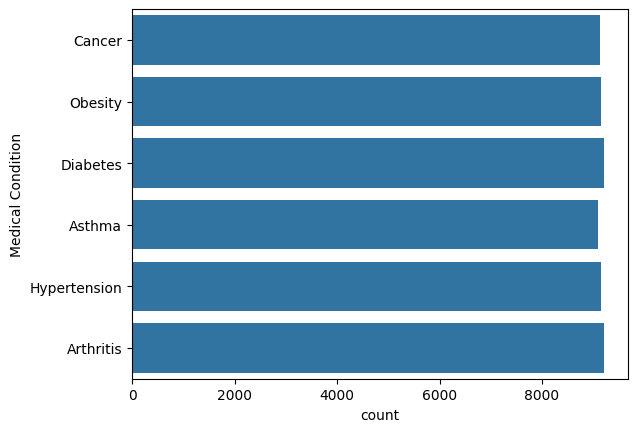

In [19]:
sns.countplot(y="Medical Condition", data=df)
plt.show()

In [20]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Medical Condition"] = le.fit_transform(df["Medical Condition"])
df["Admission Type"] = le.fit_transform(df["Admission Type"])
df["Test Results"] = le.fit_transform(df["Test Results"])

In [21]:
X = df[["Age", "Gender", "Medical Condition", "Billing Amount", "Admission Type"]]
y = df["Test Results"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.3721120611242496


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.39      0.38      3616
           1       0.37      0.37      0.37      3682
           2       0.37      0.36      0.37      3696

    accuracy                           0.37     10994
   macro avg       0.37      0.37      0.37     10994
weighted avg       0.37      0.37      0.37     10994

